# 06 Visualizing PCs

In [91]:
import numpy as np
import scipy as sp
import pandas as pd
import sys
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import pickle as pkl
from collections import defaultdict

from statsmodels.api import OLS

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score, r2_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

sys.path.append('../..')
from nonlinear_significance.scripts.TreeTester import TreeTester
from nonlinear_significance.scripts.util import TreeTransformer

from simulations_util import *

In [417]:
def run_sims(reg_func, n_grid, p, params, k=0, target_func=None, c=10, n_runs=10):
    results = defaultdict(list)
    for n in tqdm(n_grid):
        for r in range(n_runs):
            pca_results, tree_transformer = run_sim(reg_func, n, p, params, k, target_func, c, random_seed=405+r)
            results[n].append({"pca_results": pca_results,
                               "tree_transformer": tree_transformer})
    return results

def run_sim(reg_func, n, p, params, k=0, target_func=None, c=10, random_seed=405):
    np.random.seed(random_seed)
    X = np.random.randn(n, p)
    y = reg_func(X, **params)

    return get_pca_results(X, y, k, target_func, c, random_seed)


def get_pca_results(X, y, k=0, target_func=None, c=10, random_seed=405):

    if target_func is None:
        def f(Z):
            return Z[:, k]
        target_func = f

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=random_seed)
    rf_model = RandomForestRegressor(max_features=0.33, random_state=random_seed)
    rf_model.fit(X_train, y_train)
    tree_transformer = TreeTransformer(rf_model, max_components=c)
    tree_transformer.fit(X_val, y_val)
    lin_fit = OLS(y_val, tree_transformer.transform_one_feature(X_val, k)).fit()
    pca_var_explained = tree_transformer.pca_transformers[k].explained_variance_ratio_[:c]
    original_feat = X_val[:, k]
    target = target_func(X_val)
    engineered_feats = tree_transformer.transform_one_feature(X_val, k)

    y_var_explained = np.zeros(c)
    y_var_explained_normalized = np.zeros(c)
    correlation = np.zeros(c)
    correlation_w_target = np.zeros(c)
    for i in range(c):
        pc = engineered_feats[:, i]
        correlation[i] = np.corrcoef(original_feat, pc)[0,1]
        correlation_w_target[i] = np.corrcoef(target, pc)[0,1]
        single_OLS = OLS(y_val, engineered_feats[:, i]).fit()
        y_var_explained[i] = single_OLS.rsquared
        y_var_explained_normalized[i] = frac_explainable_var(y_val, target, pc)
    pca_results = pd.DataFrame({"pca_var_exp": pca_var_explained,
                                "corr_with_base_feat": correlation,
                                "corr_with_target": correlation_w_target,
                                "y_var_explained": y_var_explained,
                                "y_var_exp_norm": y_var_explained_normalized,
                                "t-statistic" : lin_fit.tvalues[:c]})

    return pca_results, tree_transformer

def frac_explainable_var(y, target, pc):

    explainable_var = np.corrcoef(y, target)[0, 1] ** 2
    explained_var = np.corrcoef(y, pc)[0, 1] ** 2

    return explained_var / explainable_var


def make_pca_variance_plot(results, n, save=False, experiment=None):

    c = results[n][0]["pca_results"].shape[0]
    nruns = len(results[n])
    cum_variances = np.zeros((nruns, c+1))
    for j, result in enumerate(results[n]):
        cum_variances[j, :] = np.cumsum(np.concatenate([[0], result["pca_results"]["pca_var_exp"]]))
    means = cum_variances.mean(axis=0)
    stds = cum_variances.std(axis=0)
    plt.errorbar(x=range(c+1), y=means, yerr=stds)
    plt.xlabel("No. of components")
    plt.ylabel("% variance explained")
    if save:
        plt.savefig(f"plots/{experiment}_pca_variance_plot.png")
    plt.show()
    return means, stds


def make_2d_plot(tree_transformer, X_val, c_plotted=6, save=False, experiment=None):
    nrow = 2
    ncol = c_plotted // nrow
    fig, axes = plt.subplots(nrow, ncol, sharex=True, sharey=True, figsize=(4*ncol, 4*nrow), constrained_layout=True)
    cmap=cm.get_cmap('viridis')
    normalizer=Normalize(-10,10)
    im=cm.ScalarMappable(norm=normalizer)
    for k in range(c_plotted):
        i = k // ncol
        j = k % ncol
        ax = axes[i, j]
        ax.scatter(X_val[:, 0], X_val[:, 1], c=tree_transformer.transform_one_feature(X_val, 0)[:,k], cmap=cmap, norm=normalizer)
        ax.set_title(f"PC {k}")
        # ax.annotate("Test", xy=(0,0))
    fig.colorbar(im, ax=axes[:, ncol-1], shrink=0.8)
    if save:
        plt.savefig(f"{experiment}_PCs.png")
    plt.show()

def make_plot(tree_transformer, X_val, c_plotted=6, original_feat=0, reference_feat=0, save=False, experiment=None):
    nrow = 2
    ncol = c_plotted // nrow
    fig, axes = plt.subplots(nrow, ncol, sharex=True, sharey=True, figsize=(4*ncol, 4*nrow), constrained_layout=True)
    for k in range(c_plotted):
        i = k // ncol
        j = k % ncol
        ax = axes[i, j]
        ax.scatter(X_val[:, original_feat], tree_transformer.transform_one_feature(X_val, reference_feat)[:,k])
        ax.set_title(f"PC {k}")
    if save:
        plt.savefig(f"{experiment}_PCs.png")
    plt.show()


def plot_across_runs(results, X, vary_n=False, pc_no=0, original_feat=0, reference_feat=0,
                     n=200, r=0, ylim=None, save=False, experiment_name=None):
    if vary_n:
        c_plotted = len(results.keys())
    else:
        c_plotted = len(list(results.values())[0])
    nrow = 2
    ncol = c_plotted // nrow
    fig, axes = plt.subplots(nrow, ncol, sharex=True, sharey=True, figsize=(4*ncol, 4*nrow), constrained_layout=True)
    for k in range(c_plotted):
        i = k // ncol
        j = k % ncol
        ax = axes[i, j]
        if vary_n:
            tree_transformer = list(results.values())[k][r]["tree_transformer"]
            pc = tree_transformer.transform_one_feature(X, reference_feat)[:, pc_no]
            ax.set_title(f"n={list(results.keys())[k]}")
        else:
            tree_transformer = results[n][k]["tree_transformer"]
            pc = tree_transformer.transform_one_feature(X, reference_feat)[:, pc_no]
            ax.set_title(f"run {k}")
        ax.scatter(X[:, original_feat], pc)
        if ylim is not None:
            ax.set_ylim(ylim)
    if save:
        plt.savefig(f"plots/{experiment_name}.png")
    plt.show()

## 1. Linear model

In [349]:
n_grid = [100, 200, 400, 800]
p = 10
k = 0
params = {"s": 2,
          "sigma": 5,
          "beta": 1}
results = run_sims(linear_model, n_grid, p, params, k)
output_file = "results/lin_pca_experiment.pkl"
pkl.dump(results, open(output_file, "wb"))
# results = pkl.load(open(output_file, "rb"))

100%|██████████| 4/4 [01:02<00:00, 15.67s/it]


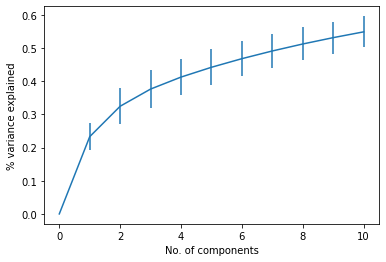

In [373]:
means, stds = make_pca_variance_plot(results, 200, save=True, experiment="lin")

In [355]:
results[200][0]["pca_results"].round(2)

,pca_var_exp,corr_with_base_feat,corr_with_target,y_var_explained,y_var_exp_norm,t-statistic
0,0.24,-0.93,-0.93,0.04,1.50,-4.68
1,0.08,-0.07,-0.07,0.00,0.01,-0.40
2,0.06,0.28,0.28,0.00,0.03,-0.71
3,0.04,-0.13,-0.13,0.01,0.23,1.84
4,0.03,0.07,0.07,0.00,0.06,0.95
5,0.03,0.03,0.03,0.00,0.13,1.38
6,0.02,-0.07,-0.07,0.01,0.49,-2.68
7,0.02,-0.01,-0.01,0.01,0.21,-1.73
8,0.02,-0.02,-0.02,0.01,0.40,2.42
9,0.02,-0.01,-0.01,0.03,1.06,3.93


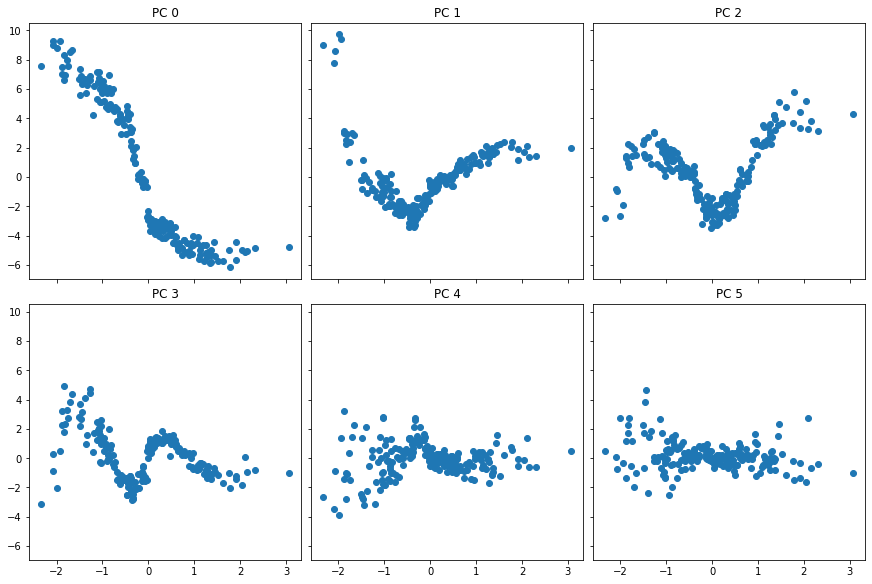

In [433]:
n = 200
X = np.random.randn(n, p)
make_plot(results[200][0]["tree_transformer"], X, c_plotted=6, save=True, experiment="lin")

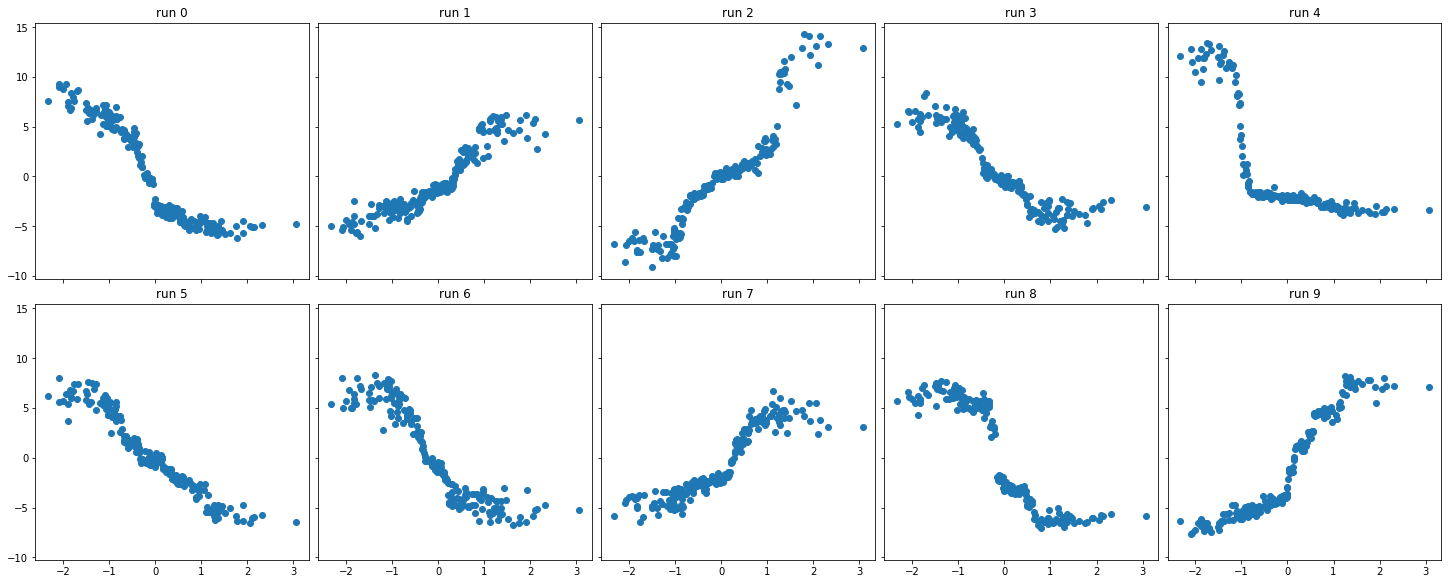

In [436]:
plot_across_runs(results, X, vary_n=False, pc_no=0, save=True, experiment_name="lin_PC0_across_runs", n=200)

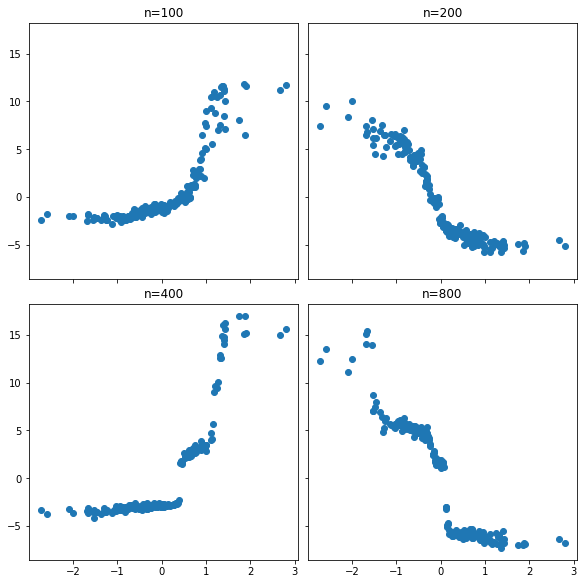

In [376]:
plot_across_runs(results, X, vary_n=True, pc_no=0, save=True, experiment_name="lin_PC0_across_n")

In [223]:
#make_2d_plot(tree_transformer, X_val, c_plotted=6, save=False, experiment="lin")

## 2. Sum of squares

In [385]:
n_grid = [100, 200, 400, 800]
p = 10
k = 0
params = {"s": 2,
          "sigma": 5,
          "beta": 1}
target_func = lambda Z : Z[:,k] ** 2
ss_results = run_sims(sum_of_squares, n_grid, p, params, k, target_func)
output_file = "results/ss_pca_experiment.pkl"
# pkl.dump(results, open(output_file, "wb"))
# results = pkl.load(open(output_file, "rb"))

100%|██████████| 4/4 [01:11<00:00, 17.90s/it]


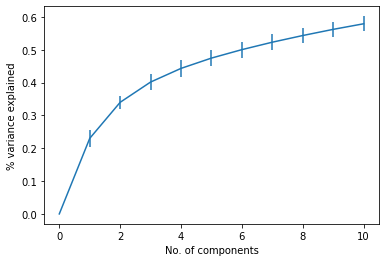

In [387]:
means, stds = make_pca_variance_plot(ss_results, 200, save=True, experiment="ss")

In [402]:
ss_results[100][1]["pca_results"].round(2)

,pca_var_exp,corr_with_base_feat,corr_with_target,y_var_explained,y_var_exp_norm,t-statistic
0,0.23,0.96,-0.20,0.01,0.31,-0.17
1,0.12,-0.19,0.93,0.02,0.64,0.24
2,0.08,0.08,-0.01,0.00,0.04,0.06
3,0.05,-0.09,-0.16,0.00,0.00,-0.02
4,0.04,-0.03,0.04,0.02,0.52,0.22
5,0.04,-0.00,0.03,0.01,0.16,0.12
6,0.03,-0.01,-0.06,0.00,0.00,0.02
7,0.03,-0.03,0.06,0.01,0.29,0.16
8,0.03,-0.07,0.06,0.00,0.04,-0.06
9,0.02,-0.00,-0.04,0.00,0.13,-0.11


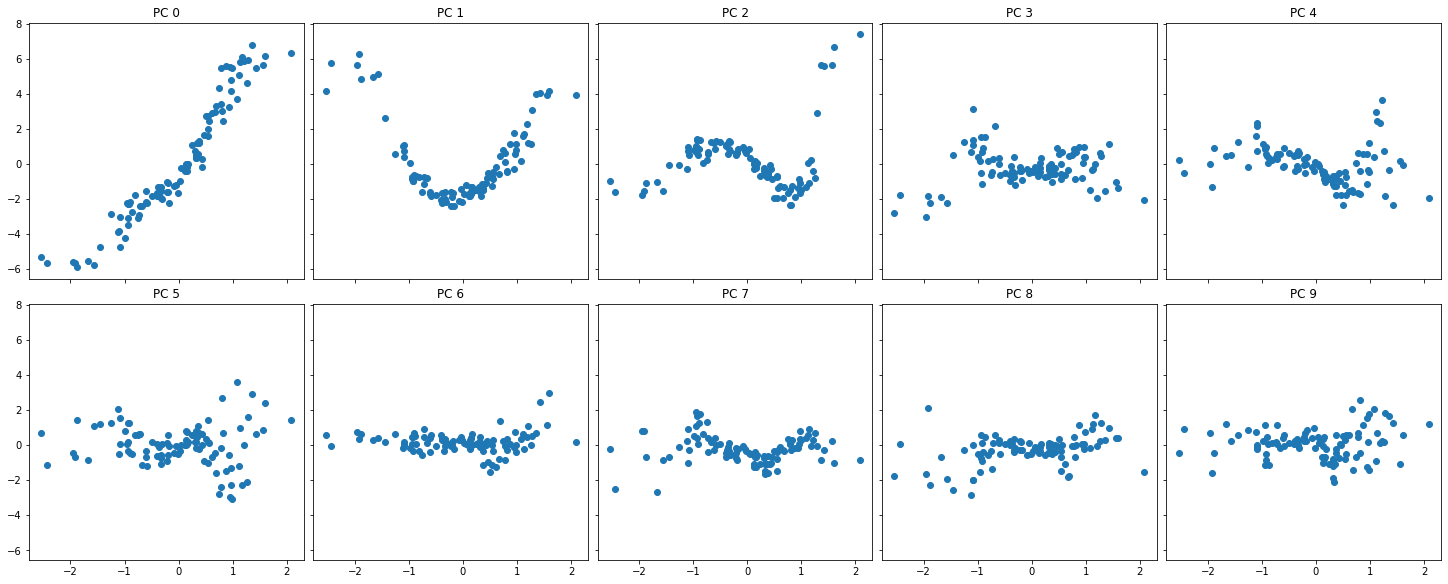

In [403]:
n = 100
X = np.random.randn(n, p)
make_plot(ss_results[n][1]["tree_transformer"], X, c_plotted=10, save=True, experiment="ss")

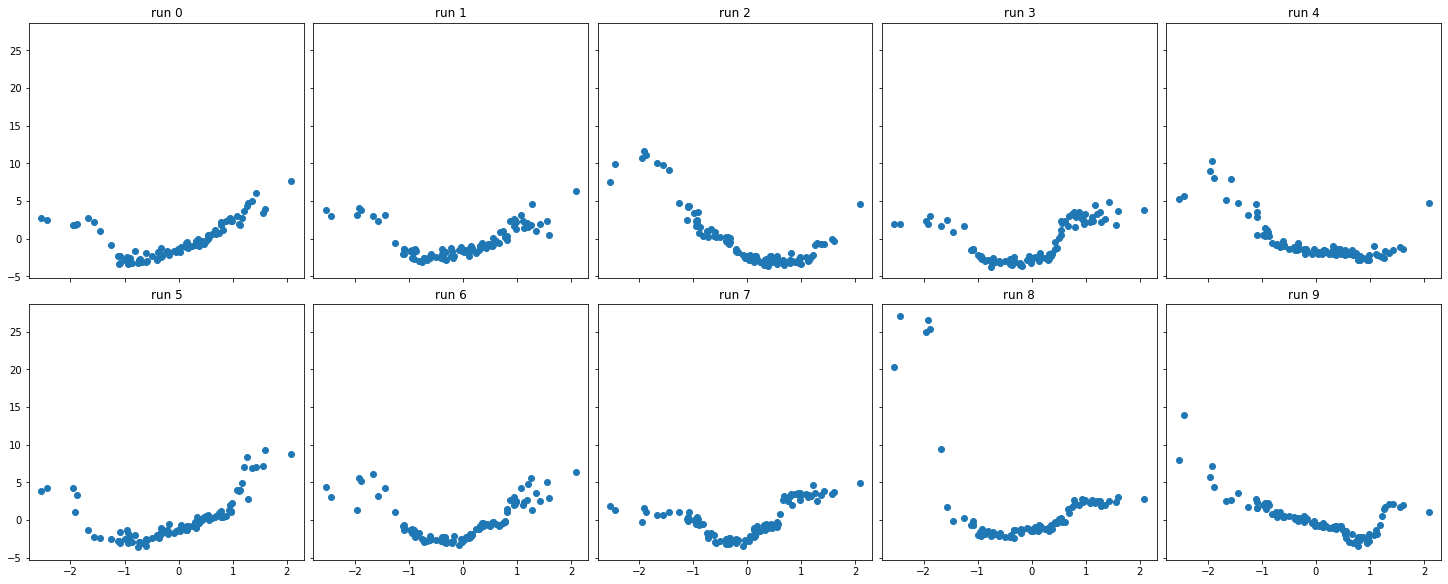

In [407]:
plot_across_runs(ss_results, X, vary_n=False, pc_no=1, save=False, experiment_name="ss_PC1_across_runs")

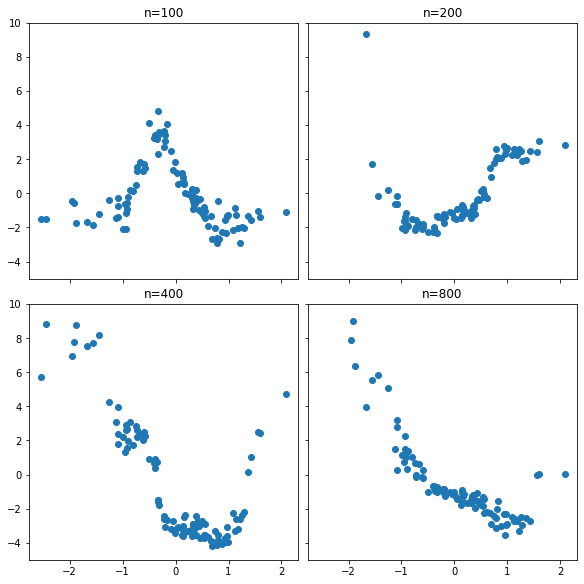

In [427]:
plot_across_runs(ss_results, X, vary_n=True, pc_no=1, save=True, experiment_name="ss_PC1_across_n", r=8, ylim=[-5,10])

## 3. LSS

In [437]:
n_grid = [100, 200, 400, 800]
p = 10
k = 0
params = {"m": 1,
          "r": 2,
          "tau": 0,
          "sigma": 1,
          "beta": 1}
target_func = lambda Z : (Z[:,k] > 0) & (Z[:,k+1] > 0)
lss_results = run_sims(lss_model, n_grid, p, params, k, target_func)
output_file = "results/lss_pca_experiment.pkl"
# pkl.dump(results, open(output_file, "wb"))
# results = pkl.load(open(output_file, "rb"))

100%|██████████| 4/4 [01:54<00:00, 28.61s/it]


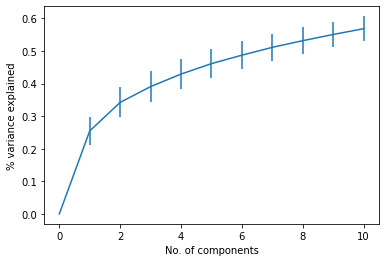

(array([0.        , 0.25466675, 0.34233232, 0.3907083 , 0.42921651,
        0.46124485, 0.4872289 , 0.51118948, 0.53172388, 0.55075654,
        0.56842303]),
 array([0.        , 0.04278107, 0.04635524, 0.04740273, 0.04582238,
        0.04504521, 0.04348052, 0.0419314 , 0.040688  , 0.03947954,
        0.03825676]))

In [438]:
make_pca_variance_plot(lss_results, 200, save=True, experiment="lss")

In [447]:
lss_results[200][0]["pca_results"].round(2)

,pca_var_exp,corr_with_base_feat,corr_with_target,y_var_explained,y_var_exp_norm,t-statistic
0,0.33,-0.89,-0.48,0.05,0.42,-0.97
1,0.08,0.24,-0.23,0.04,0.30,-0.82
2,0.04,-0.24,0.27,0.01,0.09,0.45
3,0.03,-0.11,-0.04,0.01,0.05,-0.33
4,0.03,0.12,0.36,0.01,0.08,0.42
5,0.02,-0.04,-0.25,0.00,0.02,-0.24
6,0.02,0.03,-0.03,0.00,0.01,0.14
7,0.02,0.08,-0.16,0.03,0.20,0.68
8,0.02,0.12,-0.06,0.02,0.16,-0.60
9,0.02,-0.06,0.08,0.00,0.03,-0.24


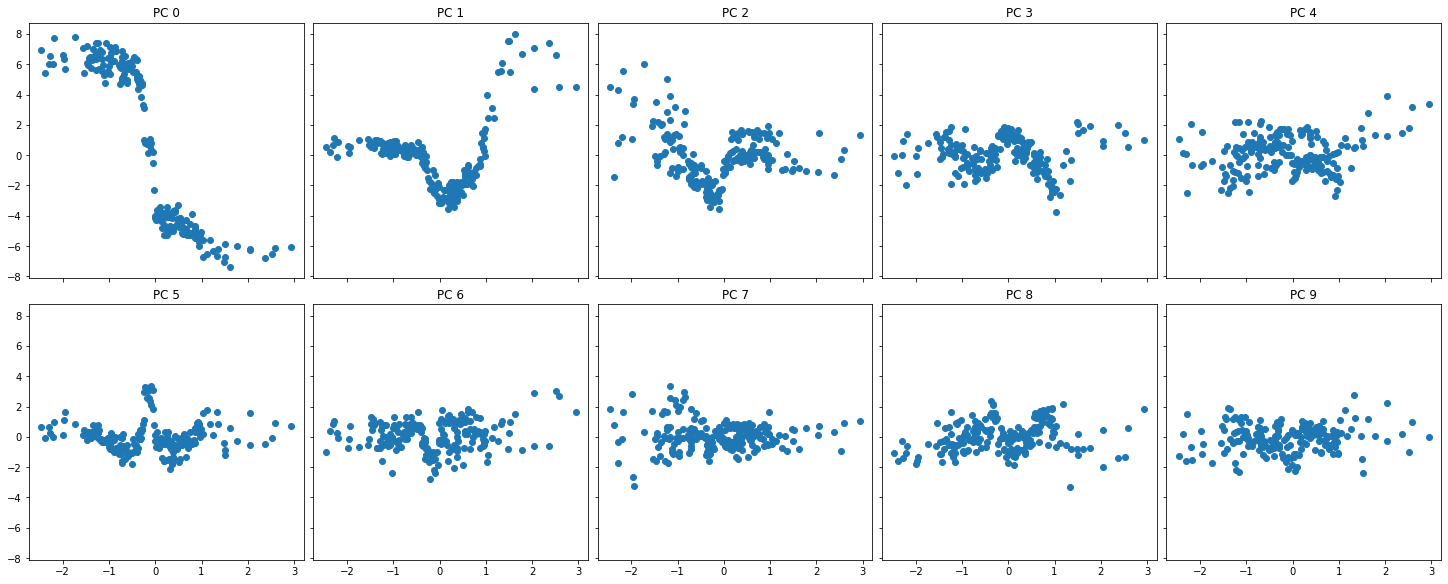

In [441]:
n = 200
X = np.random.randn(n, p)
make_plot(lss_results[n][0]["tree_transformer"], X, c_plotted=10, save=True, experiment="lss")

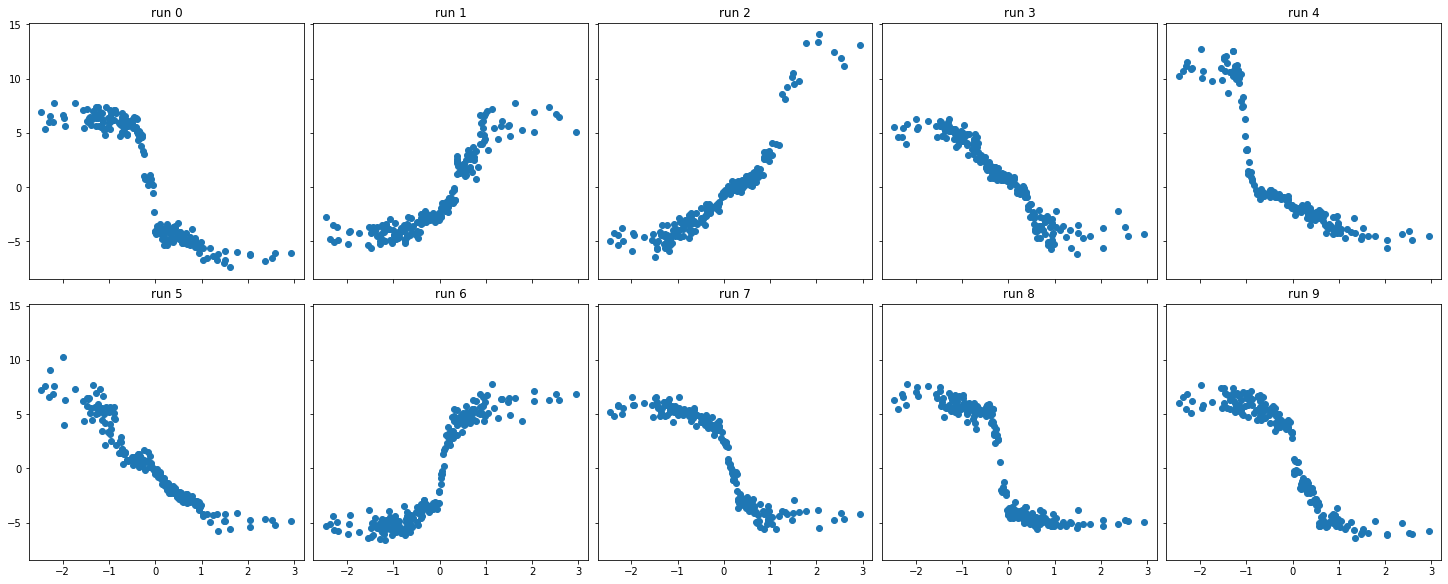

In [442]:
plot_across_runs(lss_results, X, vary_n=False, pc_no=0, save=False, experiment_name="lss_PC0_across_runs")

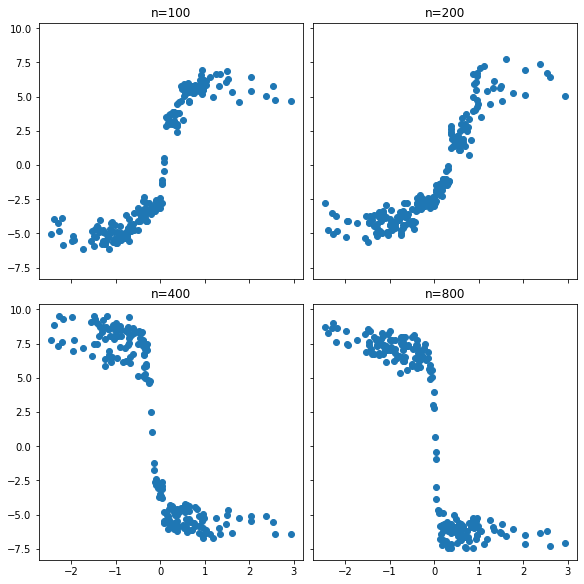

In [445]:
plot_across_runs(lss_results, X, vary_n=True, pc_no=0, save=True, experiment_name="lss_PC0_across_n", r=1)